In [24]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

# Problem 1

In [25]:
df_zillow = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-zillow-house-prices/data_zillow_house_prices.csv")
df_interest = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-interest-rates/data_interest_rates.csv")
print(f"ZIllow shape: {df_zillow.shape}")
print(f"Interest shape: {df_interest.shape}")

ZIllow shape: (893, 277)
Interest shape: (2685, 2)


In [26]:
df_zillow.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2021-11-30,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31
0,102001,0,United States,country,NaN,127881.0,128227.0,128591.0,129332.0,130079.0,...,318303.0,322658.0,327381.0,332588.0,337848.0,343392.0,348415.0,352585.0,354986.0,356026.0
1,394913,1,"New York, NY",msa,NY,224676.0,226018.0,227226.0,229604.0,231817.0,...,573600.0,576842.0,580804.0,585445.0,591876.0,599008.0,606525.0,612535.0,616856.0,619142.0
2,753899,2,"Los Angeles, CA",msa,CA,227786.0,228579.0,229794.0,232104.0,234580.0,...,845860.0,855023.0,865646.0,877802.0,895038.0,914016.0,930381.0,931707.0,928599.0,914636.0
3,394463,3,"Chicago, IL",msa,IL,170004.0,170405.0,170924.0,171963.0,173064.0,...,288807.0,291527.0,294162.0,296729.0,300023.0,303490.0,307454.0,310438.0,312286.0,312609.0
4,394514,4,"Dallas, TX",msa,TX,129921.0,130025.0,130112.0,130323.0,130544.0,...,337274.0,343129.0,350514.0,358982.0,367040.0,376487.0,385149.0,392668.0,394861.0,393920.0


In [27]:
df_interest.head()

,DATE,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [28]:
nan_zillow = df_zillow.isna().sum()
print(f"NaN in Zillow: {nan_zillow[nan_zillow > 0]}")

NaN in Zillow: StateName       1
2000-01-31    457
2000-02-29    456
2000-03-31    455
2000-04-30    453
             ... 
2021-11-30      2
2021-12-31      7
2022-01-31      3
2022-02-28      3
2022-03-31      2
Length: 268, dtype: int64


In [29]:
print(f"Regions: {df_zillow['RegionType'].unique()}")

Regions: ['country' 'msa']


In [30]:
nan_interest = df_interest.isna().sum()
print(f"NaN in interest: {nan_interest[nan_interest > 0]}")

NaN in interest: Series([], dtype: int64)


In [31]:
print(f"{df_interest["MORTGAGE30US"].describe()}")

count    2685.000000
mean        7.762004
std         3.285851
min         2.650000
25%         5.080000
50%         7.430000
75%         9.550000
max        18.630000
Name: MORTGAGE30US, dtype: float64


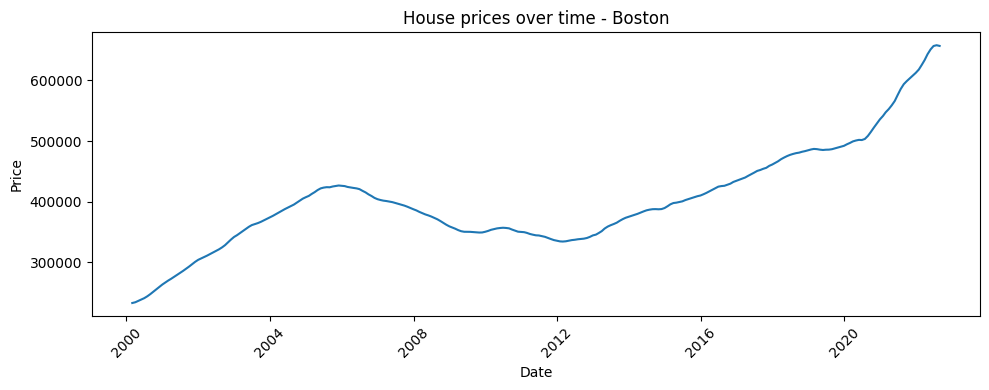

In [32]:
boston = df_zillow[df_zillow["RegionName"] == "Boston, MA"]

ts = boston.iloc[0, 6:] 

ts.index = pd.to_datetime(ts.index) 
ts = ts.sort_index()

plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values)
plt.title("House prices over time - Boston")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
from statsmodels.tsa.stattools import adfuller

ts = boston.iloc[0, 5:]
ts.index = pd.to_datetime(ts.index)
ts = ts.sort_index()

ts_2010_2017 = ts.loc["2010-01-01":"2017-12-31"]

result = adfuller(ts_2010_2017)
p_value   = result[1]

print(f"p-value: {p_value}")

p-value: 0.978724326139202


<Figure size 800x400 with 0 Axes>

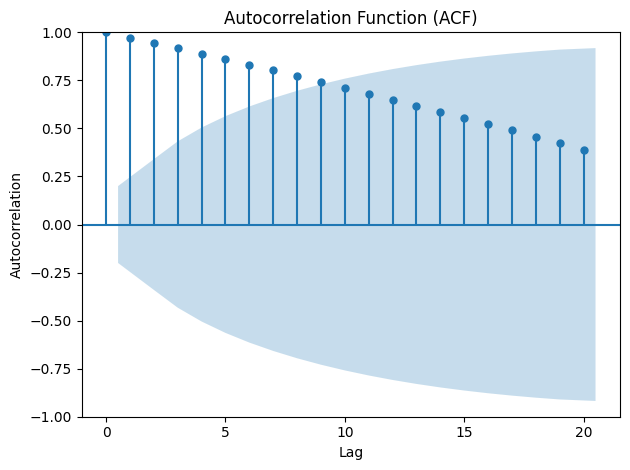

In [34]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(8, 4))
plot_acf(ts_2010_2017)  
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function (ACF)")
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

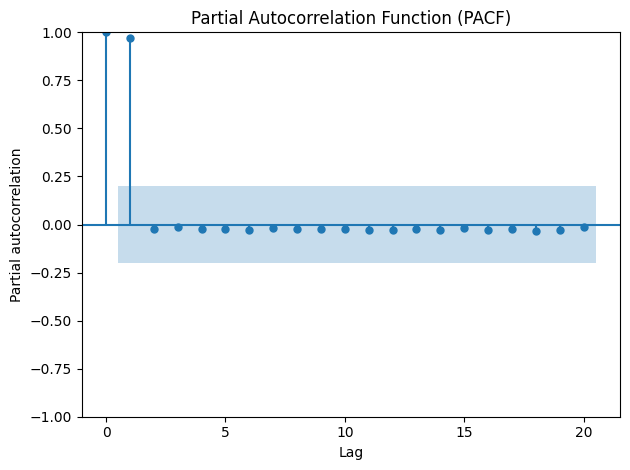

In [35]:
plt.figure(figsize=(8, 4))
plot_pacf(ts_2010_2017, lags=20, method="ywm") 
plt.xlabel("Lag")
plt.ylabel("Partial autocorrelation")
plt.title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

# Problem 2

## Model Calibration

In [36]:
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg

ts = boston.iloc[0, 5:]
ts.index = pd.to_datetime(ts.index)
ts = ts.sort_index().astype(float)
ts = ts.loc["2010-01-01":"2019-12-31"]

y = ts.values
T = len(y)
t = np.arange(1, T+1, dtype=float)

X = np.column_stack([t, t**2])
X = sm.add_constant(X)
ols = sm.OLS(y, X).fit()
trend_hat = ols.predict(X)
ts_detr = pd.Series(y - trend_hat, index=ts.index)     

train_detr = ts_detr.loc["2010-01-01":"2017-12-31"]

def mse_train(y_series, p):
    model = AutoReg(y_series, lags=p, old_names=False)
    res = model.fit()
    y_hat = res.fittedvalues     
    y_true = y_series[p:]
    mse = np.mean((y_true - y_hat)**2)
    return mse

mses = {p: mse_train(train_detr, p) for p in range(1, 6)}
mses

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

{1: np.float64(1356151.7667328885),
 2: np.float64(411293.0542615198),
 3: np.float64(414116.37219426583),
 4: np.float64(412143.67649532546),
 5: np.float64(313710.44182151766)}

In [37]:
mse1 = mses[1]               
mse1_million = mse1 / 1_000_000
round(mse1_million, 1)

np.float64(1.4)

In [38]:
best_p = min(mses, key=mses.get)
best_p

5

In [39]:
d_45 = mses[4] - mses[5]
d_34 = mses[3] - mses[4]
d_23 = mses[2] - mses[3]
d_12 = mses[1] - mses[2]

d_45, d_34, d_23, d_12

(np.float64(98433.2346738078),
 np.float64(1972.6956989403698),
 np.float64(-2823.317932746024),
 np.float64(944858.7124713687))

The optimal choice is $p = 2$ because the training MSE drops sharply from $p = 1$ to $p = 2$, while higher orders only bring negligible or no improvement, so AR(2) is the most parsimonious model.

## Time-Series Prediction

In [45]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

ts = ts.loc["2010-01-01":"2019-12-31"]
ts = ts.astype(float).dropna()

T = len(ts)
t = np.arange(1, T+1, dtype=float)
X = np.column_stack([t, t**2])
X = sm.add_constant(X)
ols = sm.OLS(ts.values, X).fit()
trend_hat = ols.predict(X)
ts_detr = pd.Series(ts.values - trend_hat, index=ts.index)

train = ts_detr.loc["2010-01-01":"2017-12-31"]
test  = ts_detr.loc["2018-01-01":"2019-12-31"]

p = 2

In [46]:
# Long-term
model_long = ARIMA(train, order=(p, 0, 0))
res_long = model_long.fit()

pred_long = res_long.predict(start=test.index[0], end=test.index[-1])

# MSE May 2018
test_may = test.loc["2018-05-01":"2018-05-31"]
pred_may_long = pred_long.loc["2018-05-01":"2018-05-31"]
mse_long_may = np.mean((test_may - pred_may_long)**2)
mse_long_may_thousand = round(mse_long_may / 1_000, 2)

# MSE-test(p)
mse_test_long = np.mean((test - pred_long)**2)
mse_test_long_thousand = round(mse_test_long / 1_000, 2)

mse_long_may_thousand, mse_test_long_thousand

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


(np.float64(0.01), np.float64(0.11))

In [47]:
# Short-term
history = train.copy()
pred_short_list = []

for date, y_true in test.items():
    model = ARIMA(history, order=(p, 0, 0))
    res = model.fit()
    y_pred = res.forecast(steps=1)[0]
    pred_short_list.append((date, y_pred))
    history.loc[date] = y_true

pred_short = pd.Series(
    [v for d, v in pred_short_list],
    index=[d for d, v in pred_short_list]
)

# MSE May 2018
pred_may_short = pred_short.loc["2018-05-01":"2018-05-31"]
mse_short_may = np.mean((test_may - pred_may_short)**2)
mse_short_may_thousand = round(mse_short_may / 1_000, 2)

# MSE-test(p) 
mse_test_short = np.mean((test - pred_short)**2)
mse_test_short_thousand = round(mse_test_short / 1_000, 2)

mse_short_may_thousand, mse_test_short_thousand

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_55/3529160949.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = res.forecast(steps=1)[0]
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarn

(np.float64(0.0), np.float64(0.0))